# Messages per User

Visualization of message counts per user (anonymized with hashed identifiers).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib.ticker import FuncFormatter

space_fmt = FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " "))

In [2]:
def load_user_counts(path):
    df = pd.read_csv(path)
    return df.sort_values("post_count", ascending=False)


df_ia = load_user_counts("../data/messages_per_user_ia.csv")
df_nwa = load_user_counts("../data/messages_per_user_nwa.csv")


def print_stats(df, label):
    print(f"{label}")
    print(f"  Total unique users: {len(df):,}")
    print(f"  Total posts:        {df['post_count'].sum():,}")
    print(f"  Users with name:    {df['hashed_name'].notna().sum():,}")
    print(f"  Users with email:   {df['hashed_email'].notna().sum():,}")


print_stats(df_ia, "IA")
print_stats(df_nwa, "NWA")

nwa_pct = df_nwa["post_count"].sum() / df_ia["post_count"].sum() * 100

print(f"NWA is {nwa_pct:.1f}% the size of IA by number of posts")

IA
  Total unique users: 239,011
  Total posts:        5,985,471
  Users with name:    189,321
  Users with email:   238,962
NWA
  Total unique users: 49,856
  Total posts:        613,626
  Users with name:    27,831
  Users with email:   49,850
NWA is 10.3% the size of IA by number of posts


# Post counts for top 20 posters

In [3]:
n = 20
print(f"Number of posts by top {n} posters in Internet Archive data")
print(df_ia.head(n).reset_index().post_count.apply(space_fmt))

Number of posts by top 20 posters in Internet Archive data
0     44 030
1     28 817
2     26 271
3     22 906
4     20 663
5     18 468
6     17 374
7     16 239
8     15 432
9     14 229
10    14 176
11    13 848
12    13 403
13    13 172
14    12 920
15    12 577
16    12 238
17    11 885
18    11 640
19    11 036
Name: post_count, dtype: object


In [4]:
print(f"Number of posts by top {n} posters in Norwegian Web Archive data")
print(df_nwa.head(n).reset_index().post_count.apply(space_fmt))

Number of posts by top 20 posters in Norwegian Web Archive data
0     5 612
1     4 349
2     3 784
3     2 975
4     2 451
5     2 410
6     2 387
7     2 384
8     1 947
9     1 920
10    1 888
11    1 731
12    1 673
13    1 652
14    1 607
15    1 464
16    1 416
17    1 389
18    1 389
19    1 343
Name: post_count, dtype: object


# Plot top n vs rest

In [5]:
def plot_top_vs_rest(df, n, title):
    top_sum = df.head(n)["post_count"].sum()
    rest_sum = df.iloc[n:]["post_count"].sum()
    rest_label = f"Rest ({len(df) - n:,} users)".replace(",", " ")
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.bar([f"Top {n} users", rest_label], [top_sum, rest_sum])
    ax.yaxis.set_major_formatter(space_fmt)
    for i, v in enumerate([top_sum, rest_sum]):
        ax.text(i, v, f"{v:,}".replace(",", " "), ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Total Posts")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

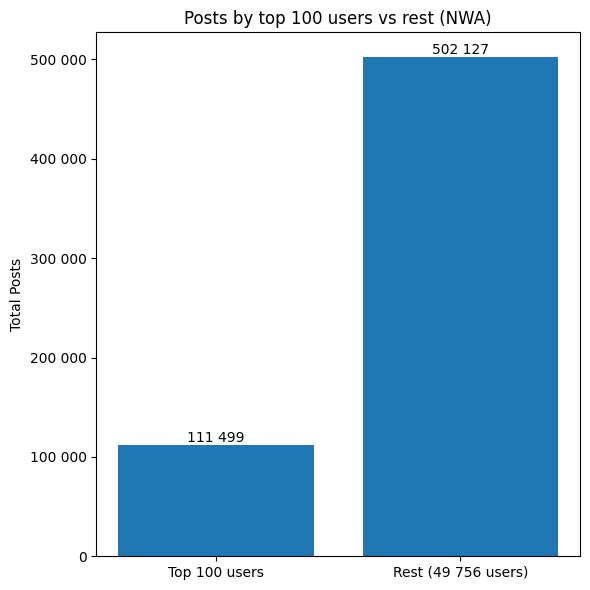

In [6]:
n = 100

plot_top_vs_rest(df_nwa, n, f"Posts by top {n} users vs rest (NWA)")

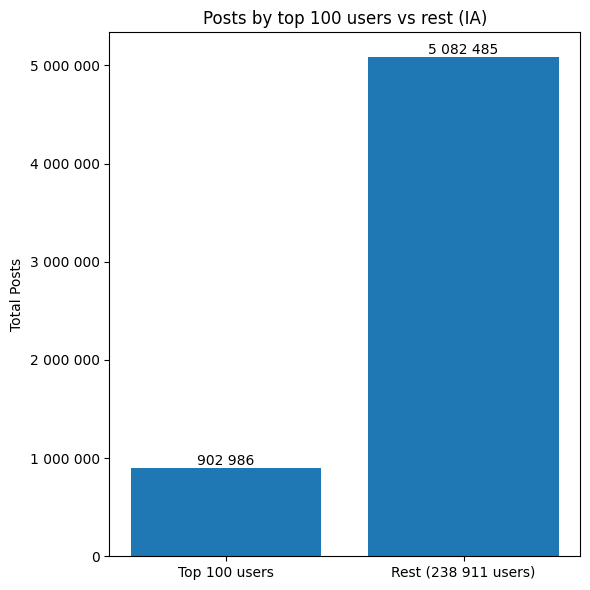

In [7]:
plot_top_vs_rest(df_ia, n, f"Posts by top {n} users vs rest (IA)")

# Cumulative distribution

In [8]:
fig = go.Figure()

for df, label in [(df_ia, "IA"), (df_nwa, "NWA")]:
    df_sorted = df.sort_values("post_count", ascending=False).reset_index(drop=True)
    df_sorted["cumulative_pct"] = (
        df_sorted["post_count"].cumsum() / df_sorted["post_count"].sum() * 100
    )
    fig.add_trace(
        go.Scatter(
            x=df_sorted.index + 1,
            y=df_sorted["cumulative_pct"],
            mode="lines",
            name=label,
        )
    )

fig.add_hline(y=50, line_dash="dash", line_color="red", annotation_text="50%")
fig.add_hline(y=80, line_dash="dash", line_color="green", annotation_text="80%")
fig.update_layout(
    title="Cumulative Post Distribution",
    xaxis_title="Number of Top Users",
    yaxis_title="Cumulative % of All Posts",
)
fig.show()

In [9]:
for df, label in [(df_ia, "IA"), (df_nwa, "NWA")]:
    df_sorted = df.sort_values("post_count", ascending=False).reset_index(drop=True)
    df_sorted["cumulative_pct"] = (
        df_sorted["post_count"].cumsum() / df_sorted["post_count"].sum() * 100
    )
    n = len(df_sorted)
    users_50 = (df_sorted["cumulative_pct"] >= 50).idxmax() + 1
    users_80 = (df_sorted["cumulative_pct"] >= 80).idxmax() + 1
    print(
        f"{label}: top {users_50:,} users ({users_50 / n * 100:.2f}%) account for 50% of posts"
    )
    print(
        f"{label}: top {users_80:,} users ({users_80 / n * 100:.2f}%) account for 80% of posts"
    )

IA: top 1,884 users (0.79%) account for 50% of posts
IA: top 15,194 users (6.36%) account for 80% of posts
NWA: top 976 users (1.96%) account for 50% of posts
NWA: top 6,454 users (12.95%) account for 80% of posts


# Users in both sources

In [10]:
ia_by_email = df_ia.groupby("hashed_email")["post_count"].sum().reset_index()
nwa_by_email = df_nwa.groupby("hashed_email")["post_count"].sum().reset_index()

shared = ia_by_email.merge(nwa_by_email, on="hashed_email", suffixes=("_ia", "_nwa"))

print(f"Users in both IA and NWA (by email): {len(shared):,}")
print(
    f"  IA-only users:  {len(ia_by_email[~ia_by_email['hashed_email'].isin(shared['hashed_email'])]):,}"
)
print(
    f"  NWA-only users: {len(nwa_by_email[~nwa_by_email['hashed_email'].isin(shared['hashed_email'])]):,}"
)

Users in both IA and NWA (by email): 33,898
  IA-only users:  159,045
  NWA-only users: 9,495


In [11]:
n = 10


def display_top_shared(shared, sort_col, n, label):
    total_ia = df_ia["post_count"].sum()
    total_nwa = df_nwa["post_count"].sum()
    result = (
        shared.sort_values(sort_col, ascending=False)
        .head(n)
        .reset_index(drop=True)
        .copy()
    )
    result["pct_ia"] = (result["post_count_ia"] / total_ia * 100).map("{:.2f}%".format)
    result["pct_nwa"] = (result["post_count_nwa"] / total_nwa * 100).map(
        "{:.2f}%".format
    )
    print(f"Top {n} shared users by {label} post count")
    return result[["hashed_email", "pct_ia", "pct_nwa"]]


display_top_shared(shared, "post_count_ia", n, "IA")

Top 10 shared users by IA post count


,hashed_email,pct_ia,pct_nwa
0,898187efc071f23b,0.44%,0.96%
1,cd0e87f8c5d05016,0.38%,0.05%
2,58c767fc11c3bf5d,0.24%,0.00%
3,5594d57a7e195faf,0.23%,0.05%
4,d5cc45a6bf11c68e,0.23%,0.07%
5,b3084aad6cc7b8c5,0.20%,0.04%
6,a6e8ab38ffcba15b,0.18%,0.02%
7,898828d5347cfc54,0.17%,0.23%
8,46d85e20e54b9956,0.15%,0.03%
9,1b03ca37d7116296,0.15%,0.05%


In [12]:
display_top_shared(shared, "post_count_nwa", n, "NWA")

Top 10 shared users by NWA post count


,hashed_email,pct_ia,pct_nwa
0,898187efc071f23b,0.44%,0.96%
1,c3dd03f2a3ffd6de,0.10%,0.71%
2,8cb56259d88bffd8,0.00%,0.62%
3,d3ae2e2c5ecdd415,0.03%,0.48%
4,30d0be1ae12a7749,0.03%,0.40%
5,ad36d72860ab5776,0.07%,0.40%
6,f23e5a24dc97cafb,0.03%,0.39%
7,c06828244a65f48d,0.03%,0.39%
8,e2a7e62962e3a785,0.03%,0.34%
9,41e8a2368fb19b57,0.05%,0.32%


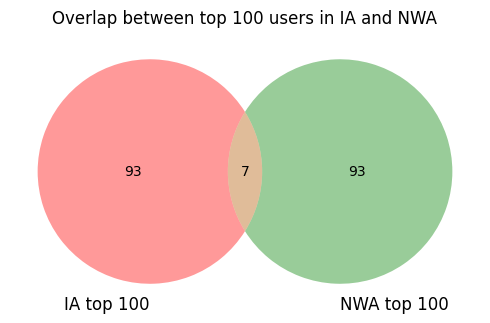

In [13]:
from matplotlib_venn import venn2

n = 100
top_ia = set(ia_by_email.nlargest(n, "post_count")["hashed_email"])
top_nwa = set(nwa_by_email.nlargest(n, "post_count")["hashed_email"])

fig, ax = plt.subplots(figsize=(5, 5))
venn2([top_ia, top_nwa], set_labels=(f"IA top {n}", f"NWA top {n}"), ax=ax)
ax.set_title(f"Overlap between top {n} users in IA and NWA")
plt.tight_layout()
plt.show()